## Unsupervised Learning: Customer Segmentation
---
# 1. INTRODUCTION
---
### What is Unsupervised Learning?
Unsupervised learning is a type of machine learning where the data has NO labels. The goal is to discover hidden patterns or groupings in the data.

### What is Clustering?
Clustering is a technique used to group similar data points together.
- Example: Grouping customers based on spending behavior.


In [1]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

# 2. LOAD REAL DATASET
---
### Dataset: Mall Customers
This dataset contains information about customers such as:
- Age
- Annual Income
- Spending Score

In [6]:
# Load dataset
df = pd.read_csv(r"C:\Users\M.faisal\Desktop\ai_ml\ai_ml_projects\3Logy-NDI-AI-ML-Crash\datasets\Shopping\shopping_mall_customer.csv")
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


In [8]:
X = df[["Age", "Annual Income", "Spending Score"]]

# 3. EDA (EXPLORATORY DATA ANALYSIS)
---
### What is EDA?
EDA is the process of understanding your data using statistics and visualization. It helps detect patterns, anomalies, and relationships.

                Age  Annual Income  Spending Score
count  15079.000000   15079.000000    15079.000000
mean      54.191591  109742.880562       50.591617
std       21.119207   52249.425866       28.726977
min       18.000000   20022.000000        1.000000
25%       36.000000   64141.000000       26.000000
50%       54.000000  109190.000000       51.000000
75%       72.000000  155008.000000       75.000000
max       90.000000  199974.000000      100.000000


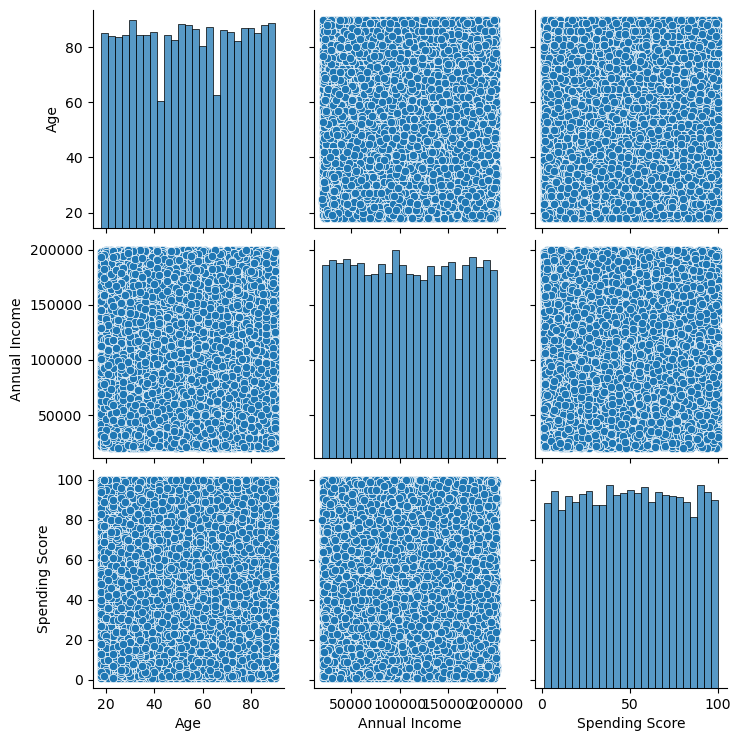

In [11]:
print(X.describe())
sns.pairplot(X)
plt.show()

In [17]:
X.shape

(15079, 3)

# 4. PREPROCESSING
---
### Why Scaling?
Clustering algorithms are distance-based. Features with larger values dominate if not scaled.

In [15]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X))

                Age  Annual Income  Spending Score
count  15079.000000   15079.000000    15079.000000
mean      54.191591  109742.880562       50.591617
std       21.119207   52249.425866       28.726977
min       18.000000   20022.000000        1.000000
25%       36.000000   64141.000000       26.000000
50%       54.000000  109190.000000       51.000000
75%       72.000000  155008.000000       75.000000
max       90.000000  199974.000000      100.000000


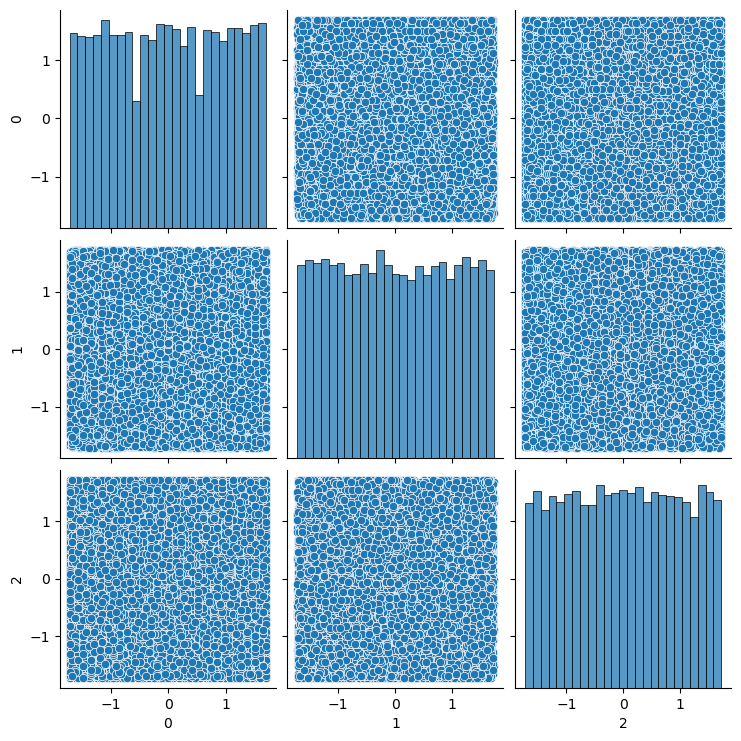

In [16]:
print(X.describe())
sns.pairplot(X_scaled)
plt.show()

# 5. ELBOW METHOD (VISUALIZING BEST K)
---
### How do we choose the BEST number of clusters (K)? 
We use a visualization called the Elbow Method.
Idea:
- As K increases, error (inertia) decreases
- At some point, improvement slows down
- That "bend" (elbow) is the optimal K

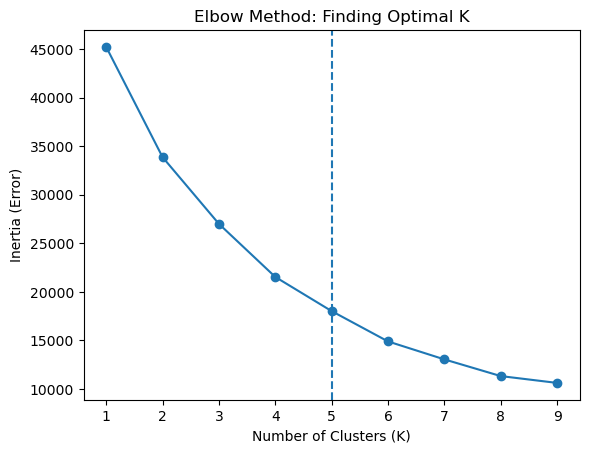

In [18]:
inertia = []
K_values = range(1, 10)

for k in K_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure()
plt.plot(K_values, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Error)")
plt.title("Elbow Method: Finding Optimal K")

# Highlight possible elbow point manually (example K=5)
plt.axvline(x=5, linestyle='--')

plt.show()

### Interpretation:
- Look for where the curve bends sharply
- That point = best balance between simplicity and performance
- Too small K → underfitting (clusters too broad)
- Too large K → overfitting (too many tiny clusters)

# 6. K-MEANS MODEL
---
### How many clusters should we choose?
From the elbow diagram above, we pick K where the curve bends.
Hence, K = 5

In [19]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

X['Cluster'] = clusters

## EXTRA: ANOTHER BEST VISUAL PLOTS FOR CHOOSING K
---
There are TWO best plots to determine optimal clusters:
1. Elbow Plot (Inertia vs K)
2. Silhouette Score Plot (Score vs K)

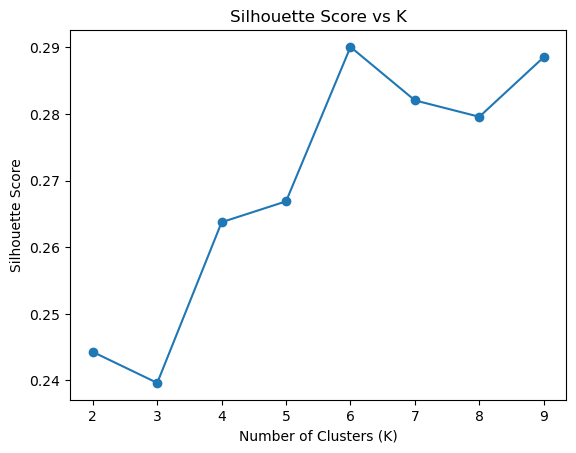

In [20]:
# --- Silhouette Score Plot ---
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure()
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

# HOW TO INTERPRET BOTH PLOTS TOGETHER
---
* Elbow Plot → shows where improvement slows down
* Silhouette Plot → shows how well-separated clusters are

### BEST PRACTICE:
- Choose K at elbow point
- Ensure silhouette score is HIGH at that K

### Example Decision:
If K=5:
- Elbow is visible at 5
- Silhouette score is near peak
→ Then K=5 is a strong choice

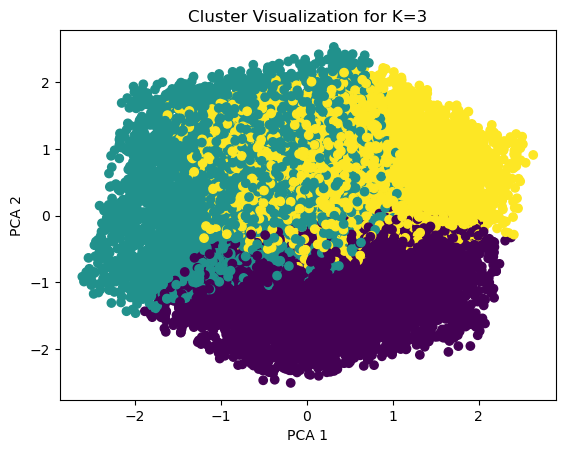

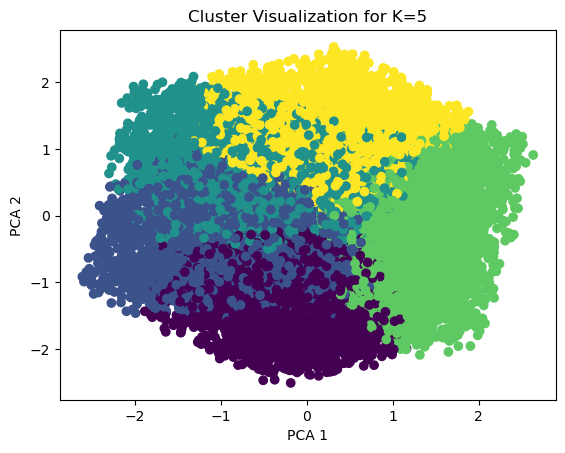

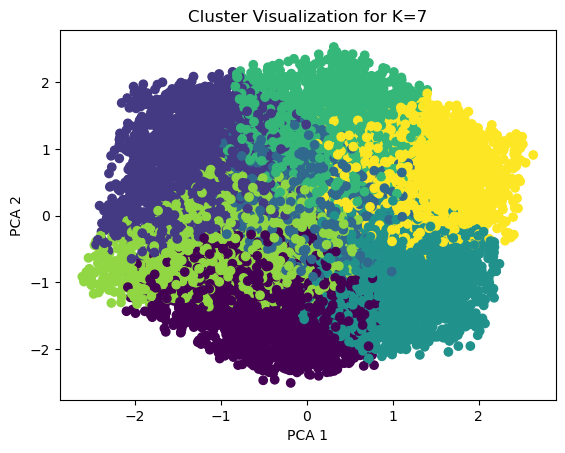

In [21]:
# VISUAL COMPARISON OF DIFFERENT K VALUES
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

for k in [3, 5, 7]:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    
    plt.figure()
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
    plt.title(f"Cluster Visualization for K={k}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()

## HOW TO DECIDE FINAL CLUSTERS
---
**Combine All**:
1. Elbow Method (visual bend)
2. Silhouette Score (quality)
3. Visualization (does it look meaningful?)
4. Business Understanding (does it make sense?)

**Golden Rule**:
- Best K is NOT just mathematical — it must be interpretable
---

**Combine Both**:
1. Elbow Method (visual bend)
2. Silhouette Score (quantitative quality)

**Best practice**:
- Choose K at elbow point
- Confirm it has a relatively HIGH silhouette score
- Ensure clusters make BUSINESS SENSE (very important!)

**Example**:
K=5 is good if:
- Clear elbow at 5
- Silhouette score is high
- Clusters represent meaningful customer groups

### How K-Means Works (Step-by-Step)
- Initialize cluster centers randomly
- Assign each point to closest center
- Update centers (mean of cluster points)
- Repeat until stable

In [22]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

X['Cluster'] = clusters

# 7. SILHOUETTE SCORE
---
### What is Silhouette Score?
It measures how well clusters are separated.
Range: -1 to 1
- Close to 1 → well-separated clusters
- Close to 0 → overlapping clusters
- Negative → wrong clustering

In [23]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.26689623156850506


# 8. DBSCAN (OUTLIER DETECTION)
---
### What is DBSCAN?
Density-Based Spatial Clustering of Applications with Noise

### How DBSCAN Works:
- Groups points that are close together (dense regions)
- Points far away are labeled as outliers (-1)

**Parameters**:
- eps: distance threshold
- min_samples: minimum points to form cluster

In [25]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
db_clusters = dbscan.fit_predict(X_scaled)

X['DBSCAN_Cluster'] = db_clusters

print("DBSCAN Labels:", set(db_clusters))

DBSCAN Labels: {np.int64(0)}


# 9. PCA VISUALIZATION
---
### What is PCA?
Principal Component Analysis reduces dimensions for visualization while preserving important information.

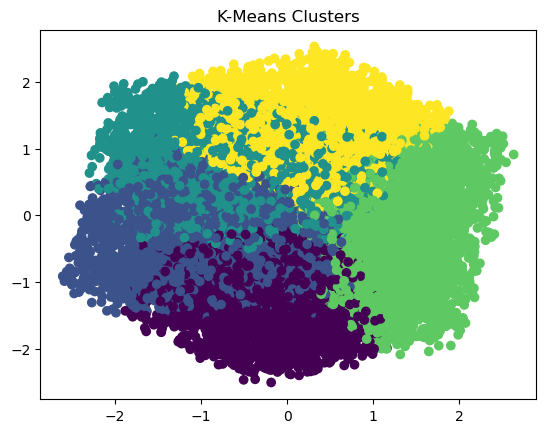

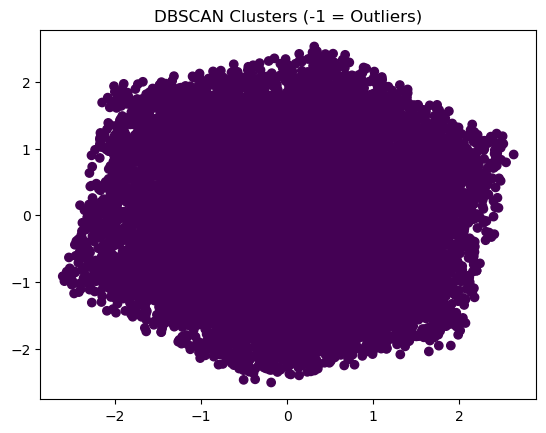

In [26]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title("K-Means Clusters")
plt.show()

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_clusters)
plt.title("DBSCAN Clusters (-1 = Outliers)")
plt.show()

# 10. CLUSTER LABELING (BUSINESS INTERPRETATION)
---
### Why Label Clusters?
Clusters are just numbers (0,1,2...). Businesses need meaningful names.

In [29]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=X.columns[:3])

print(centers_df)

# Example labeling

def label_cluster(row):
    if row['Annual Income'] > 80 and row['Spending Score'] > 60:
        return "High Value"
    elif row['Spending Score'] < 40:
        return "Low Value"
    else:
        return "Medium Value"

X['Segment'] = X.apply(label_cluster, axis=1)

         Age  Annual Income  Spending Score
0  36.766667   66608.373180       28.310728
1  53.071406   63107.712210       78.112828
2  35.014329  159679.150610       49.629878
3  73.978960  104720.997834       24.040842
4  71.844600  152316.573843       71.932035


# 11. SAVE MODEL
---
### Why Save Models?
So we can reuse them later without retraining.

In [30]:
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# 12. INFERENCE UI
---
### What is Inference?
Using a trained model to make predictions on new data.

In [32]:
import ipywidgets as widgets
from IPython.display import display

age = widgets.IntSlider(min=18, max=70, value=30, description='Age')
income = widgets.IntSlider(min=15, max=150, value=50, description='Annual Income')
score = widgets.IntSlider(min=1, max=100, value=50, description='Spending Score')
btn = widgets.Button(description="Predict")
out = widgets.Output()

model = joblib.load("kmeans_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")


def predict(b):
    with out:
        out.clear_output()
        data = np.array([[age.value, income.value, score.value]])
        scaled = scaler_loaded.transform(data)
        pred = model.predict(scaled)
        print("Cluster:", pred[0])

btn.on_click(predict)

display(age, income, score, btn, out)

IntSlider(value=30, description='Age', max=70, min=18)

IntSlider(value=50, description='Annual Income', max=150, min=15)

IntSlider(value=50, description='Spending Score', min=1)

Button(description='Predict', style=ButtonStyle())

Output()